In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

def eda(path):
    global df
    df = pd.read_csv(path)

    print("Top 5 Lines of Dataset")
    print(df.head().to_string())  # <-- to_string()
    print('-' * 30)

    print("Bottom 5 Lines of Dataset")
    print(df.tail().to_string())  # <-- to_string()
    print('-' * 30)

    print("Shape of Dataset")
    print('shape of dataset is',df.shape)
    print('-' * 30)

    print("Info of Dataset")
    df.info()  # no print() needed for info()
    print('-' * 30)

    print("Stats of Dataset")
    print(df.describe().to_string())
    print('-' * 30)

    print("Null Values of Dataset")
    print(df.isnull().sum())
    print('-' * 30)

    print("Duplicate Values of Dataset")
    print(df.duplicated().sum())
    print('-' * 30)


In [3]:
eda('ai_dev_productivity.csv')

Top 5 Lines of Dataset
   hours_coding  coffee_intake_mg  distractions  sleep_hours  commits  bugs_reported  ai_usage_hours  cognitive_load  task_success
0          5.99               600             1          5.8        2              1            0.71             5.4             1
1          4.72               568             2          6.9        5              3            1.75             4.7             1
2          6.30               560             1          8.9        2              0            2.27             2.2             1
3          8.05               600             7          6.3        9              5            1.40             5.9             0
4          4.53               421             6          6.9        4              0            1.26             6.3             1
------------------------------
Bottom 5 Lines of Dataset
     hours_coding  coffee_intake_mg  distractions  sleep_hours  commits  bugs_reported  ai_usage_hours  cognitive_load  task_success
4

In [4]:
def drop_null_values(df):
    df.dropna(inplace=True)
    print("Total Null Values After Running dropna")
    print(df.isnull().sum())
    print('-'*100)

def drop_duplicate_values(df):
    df.drop_duplicates(inplace=True)
    print("Total Duplicate Values After Running drop_duplicates")
    print(df.duplicated().sum())
    print('-'*100)

In [5]:
drop_null_values(df)
drop_duplicate_values(df)

Total Null Values After Running dropna
hours_coding        0
coffee_intake_mg    0
distractions        0
sleep_hours         0
commits             0
bugs_reported       0
ai_usage_hours      0
cognitive_load      0
task_success        0
dtype: int64
----------------------------------------------------------------------------------------------------
Total Duplicate Values After Running drop_duplicates
0
----------------------------------------------------------------------------------------------------


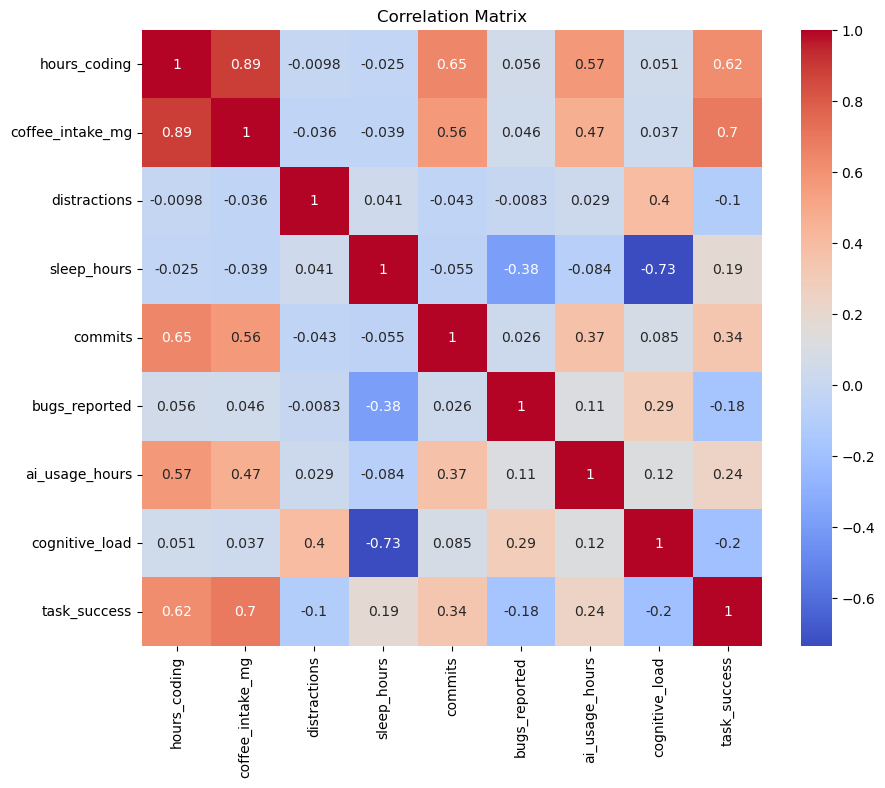

In [6]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


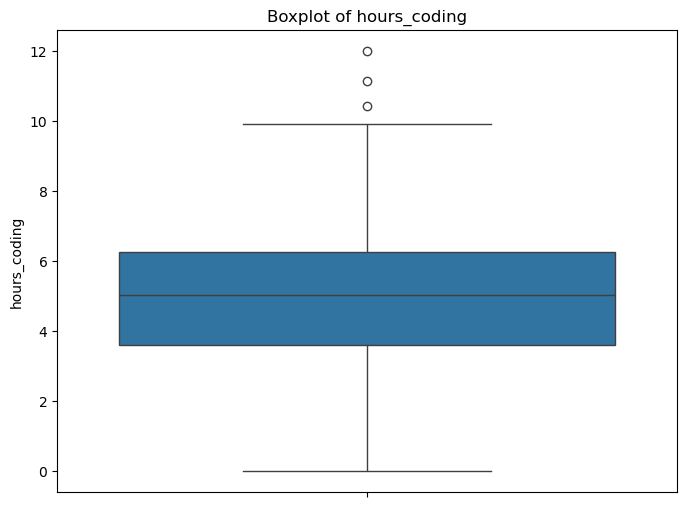

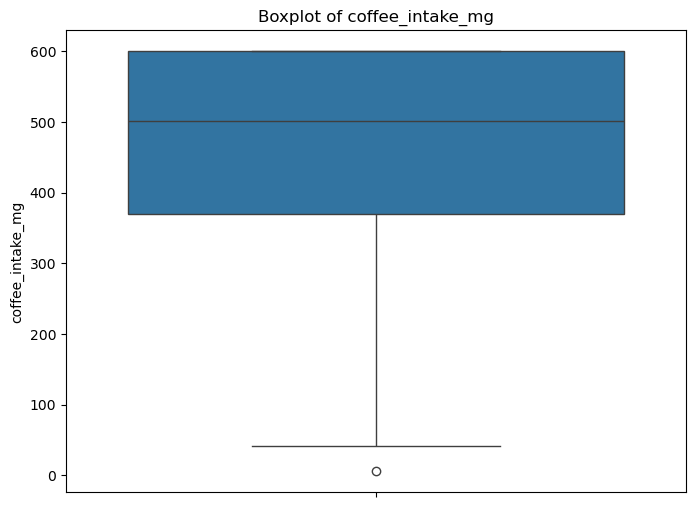

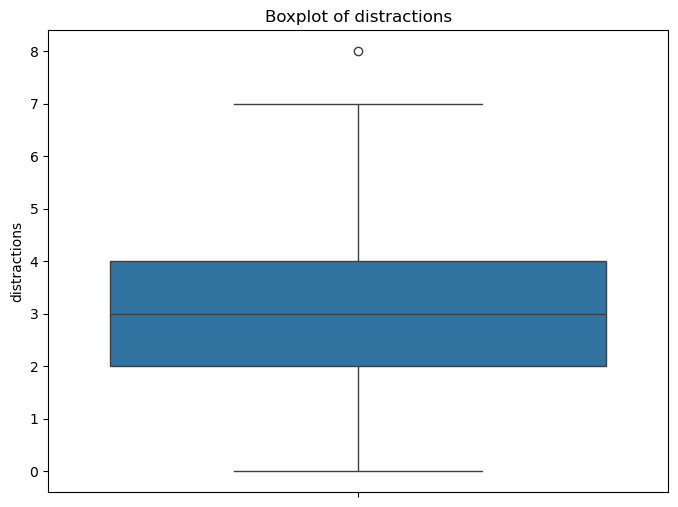

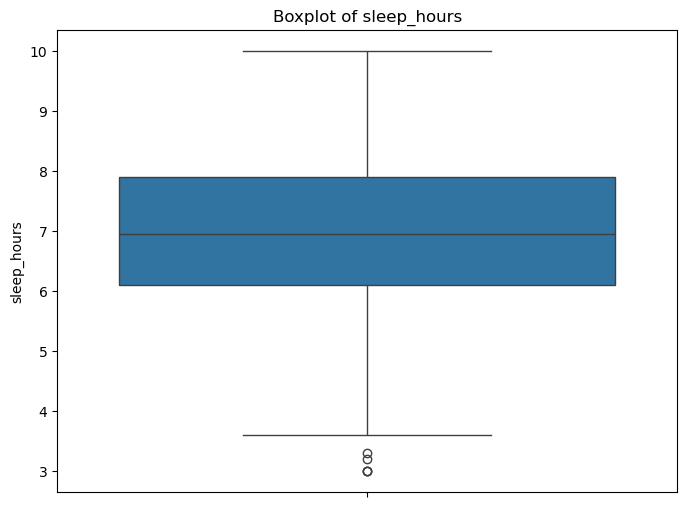

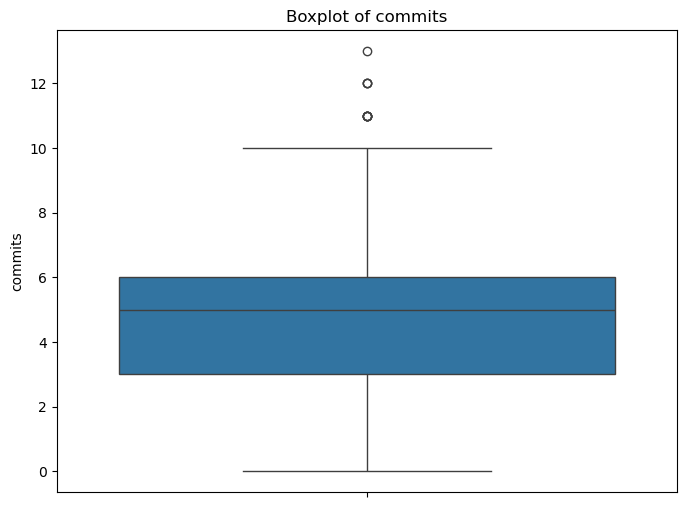

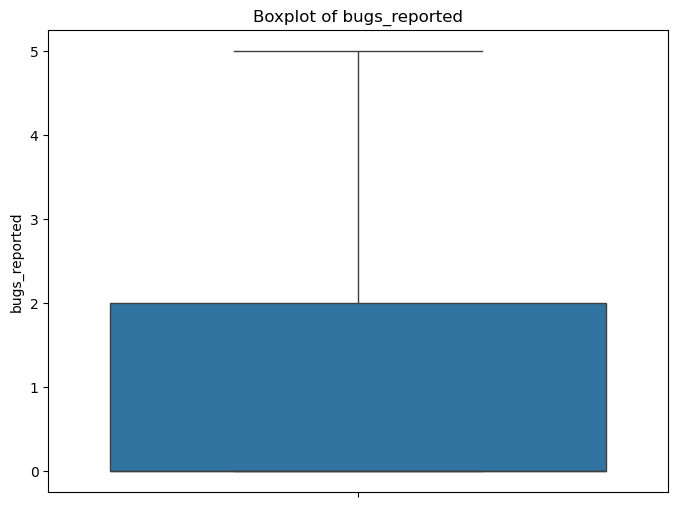

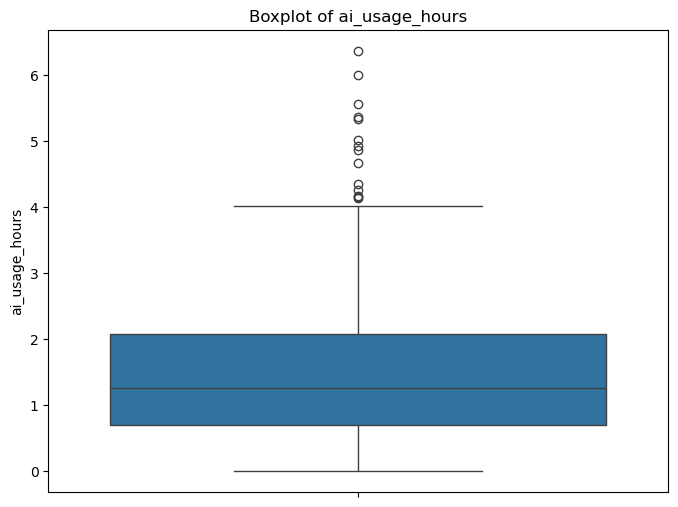

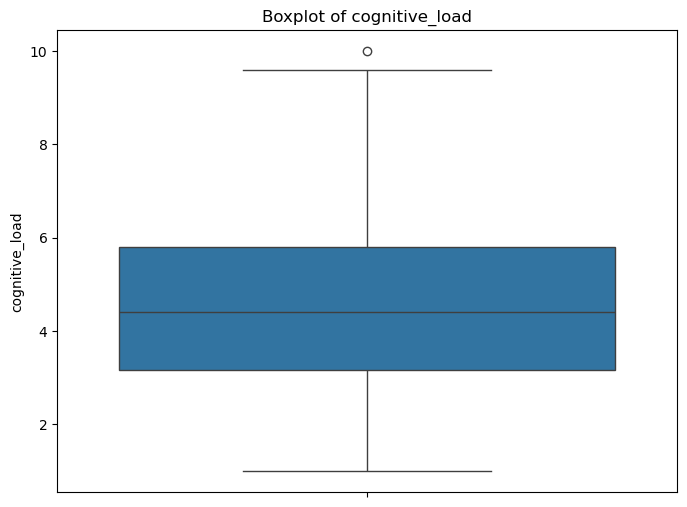

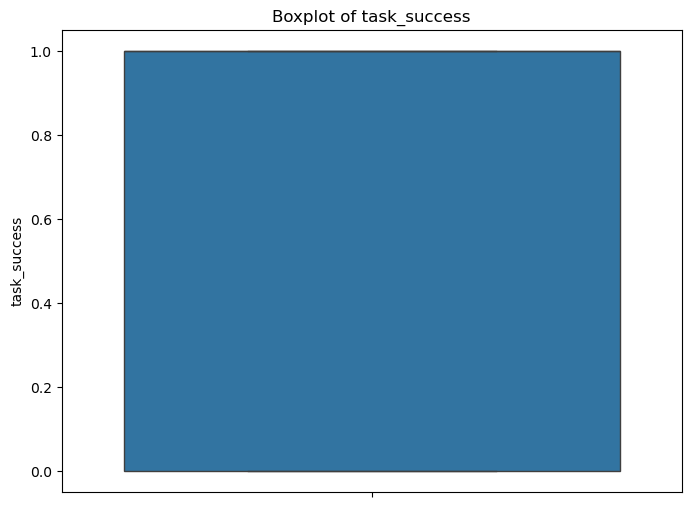

In [7]:
for i in df.columns:
    if df[i].dtype != 'object':  # Check if column is not categorical
        plt.figure(figsize=(8, 6))  # Set figure size for each plot
        sns.boxplot(y=df[i])  # Plot the boxplot for each numeric column
        plt.title(f'Boxplot of {i}')  # Title for the plot
        plt.show()

In [8]:
for i in df.columns:
  if(df[i].dtypes=='int64' or df[i].dtypes=='float64'):
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        
        IQR = Q3 - Q1
        
        # filtering out the outliers by using the reversal condition
        
        df = df[(df[i] >= Q1 - 1.5 * (IQR)) & (df[i] <= Q3 + 1.5 * (IQR))]

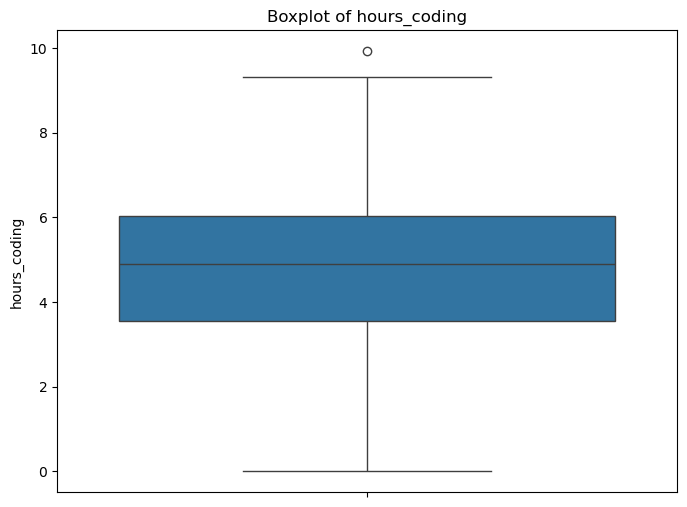

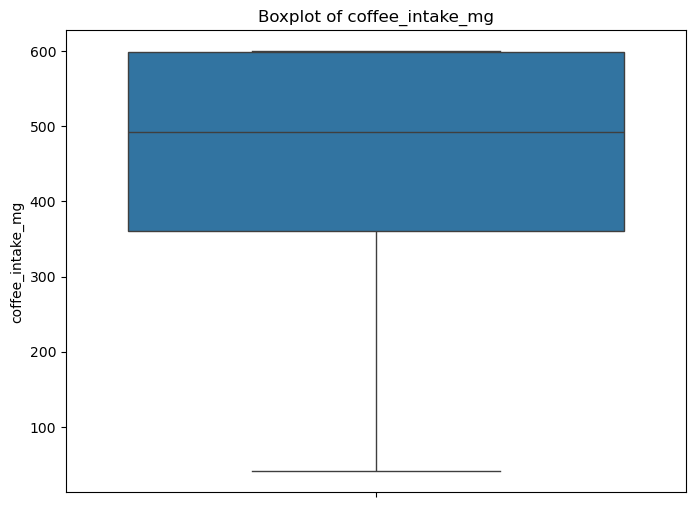

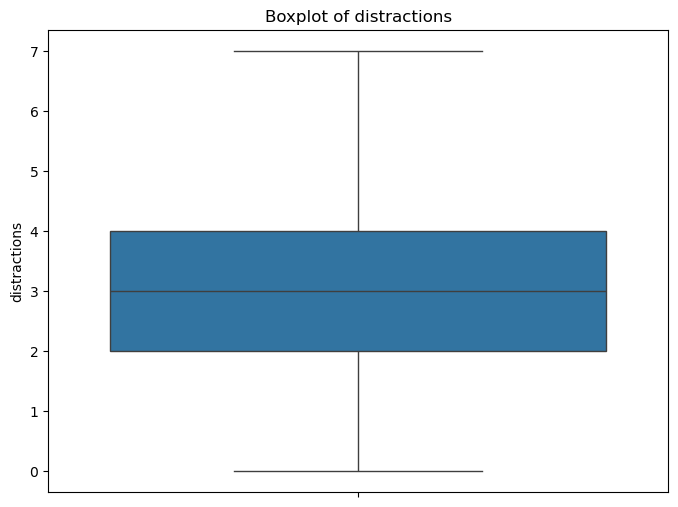

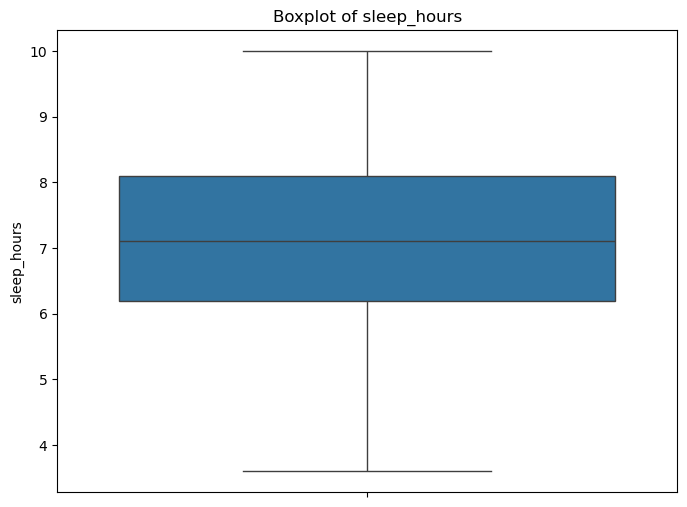

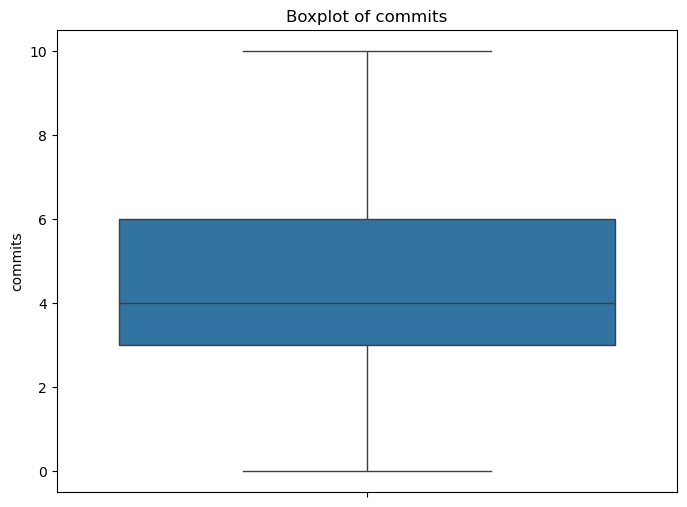

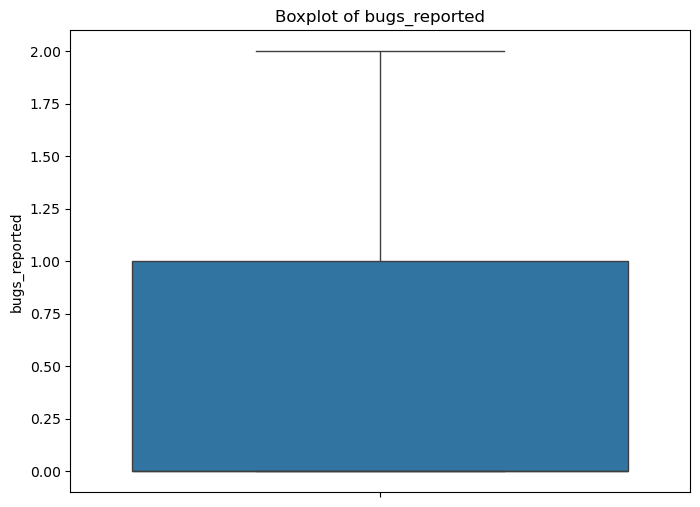

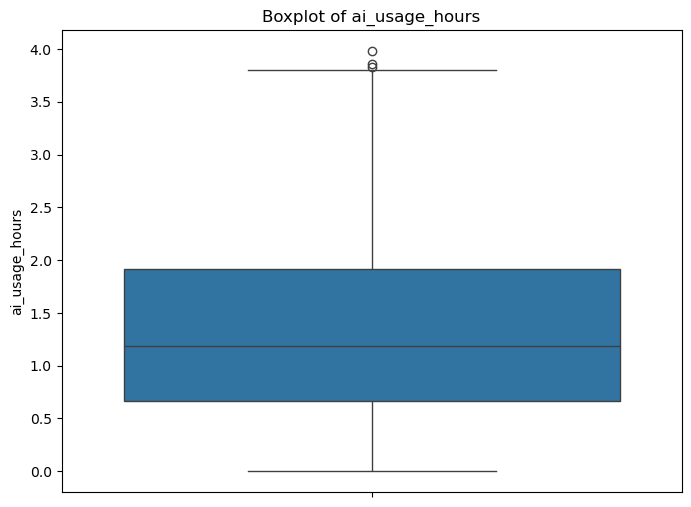

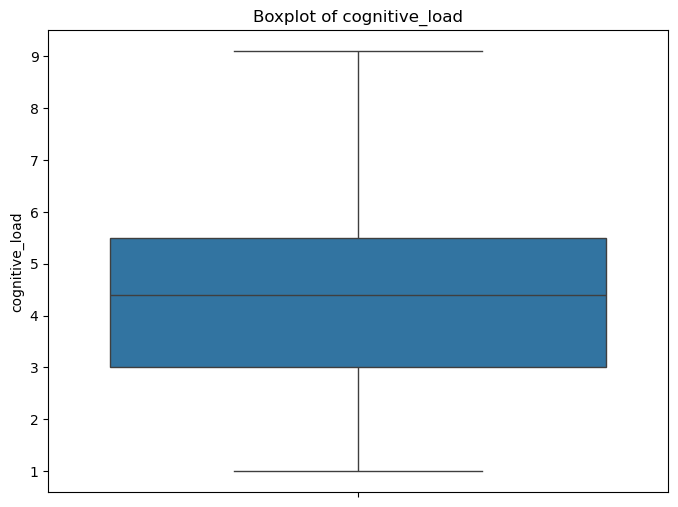

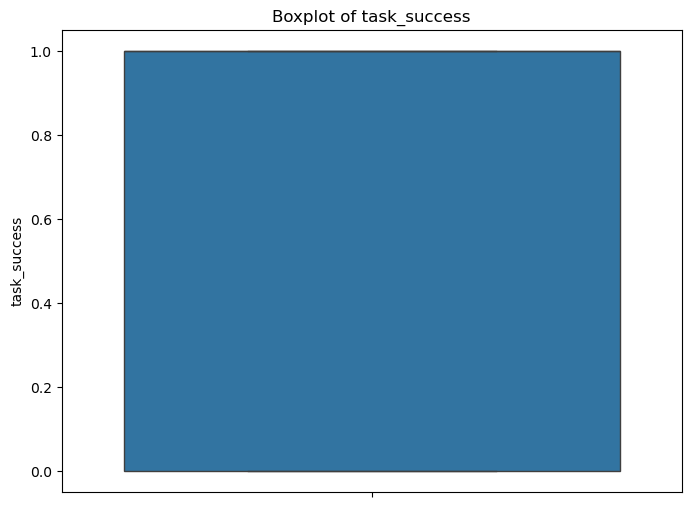

In [9]:
for i in df.columns:
    if df[i].dtype != 'object':  # Check if column is not categorical
        plt.figure(figsize=(8, 6))  # Set figure size for each plot
        sns.boxplot(y=df[i])  # Plot the boxplot for each numeric column
        plt.title(f'Boxplot of {i}')  # Title for the plot
        plt.show()

In [10]:
df

,hours_coding,coffee_intake_mg,distractions,sleep_hours,commits,bugs_reported,ai_usage_hours,cognitive_load,task_success
0,5.99,600,1,5.8,2,1,0.71,5.4,1
2,6.30,560,1,8.9,2,0,2.27,2.2,1
4,4.53,421,6,6.9,4,0,1.26,6.3,1
5,4.53,429,1,7.1,5,0,3.06,3.9,1
6,8.16,600,1,8.3,6,0,0.30,2.2,1
...,...,...,...,...,...,...,...,...,...
495,6.08,594,1,5.3,3,0,0.91,6.8,1
496,2.93,382,2,6.7,3,2,1.38,5.9,0
497,4.62,494,4,7.5,2,0,0.41,4.5,1
498,3.25,296,6,6.9,1,0,1.52,6.3,0


C:\Users\USER\AppData\Local\Temp\ipykernel_3648\2459662644.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='commits', order=df['commits'].value_counts().index, palette='pastel')


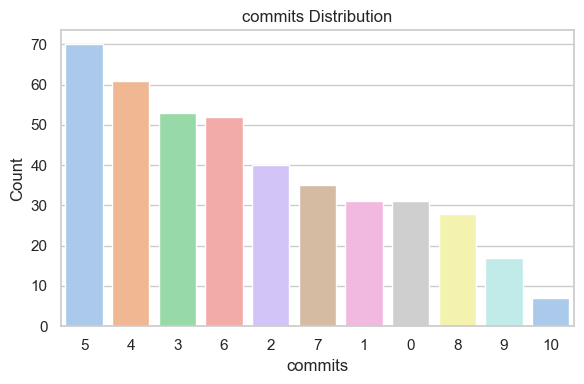

In [11]:
sns.set(style="whitegrid")

# === 1. Bar chart ===
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='commits', order=df['commits'].value_counts().index, palette='pastel')
plt.title("commits Distribution")
plt.xlabel("commits")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_3648\3194178503.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='bugs_reported', order=df['bugs_reported'].value_counts().index, palette='muted')


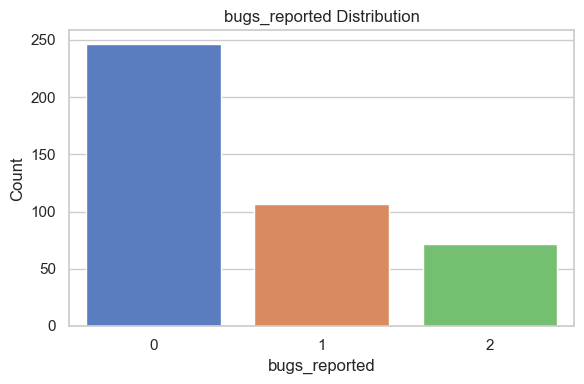

In [12]:
sns.set(style="whitegrid")

# === 2. Bar chart ===
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='bugs_reported', order=df['bugs_reported'].value_counts().index, palette='muted')
plt.title("bugs_reported Distribution")
plt.xlabel("bugs_reported")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_3648\2502153179.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='task_success', order=df['task_success'].value_counts().index, palette='muted')


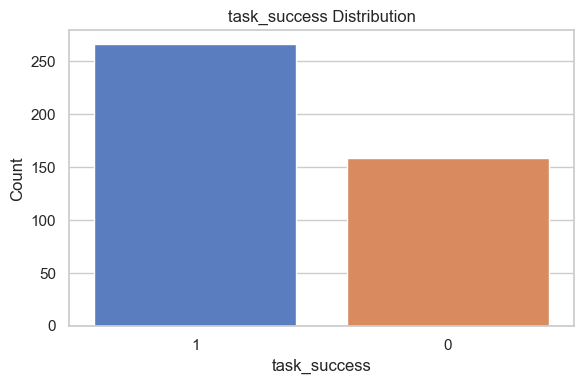

In [13]:
sns.set(style="whitegrid")

# === 2. Bar chart for species ===
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='task_success', order=df['task_success'].value_counts().index, palette='muted')
plt.title("task_success Distribution")
plt.xlabel("task_success")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

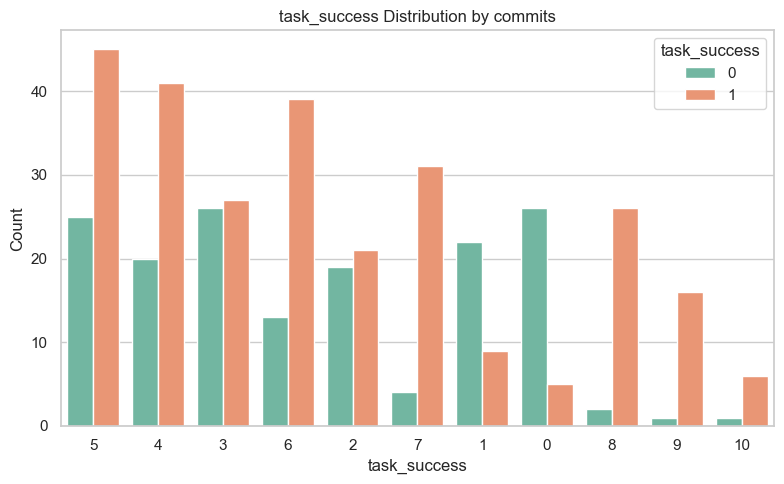

In [15]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='commits', hue='task_success',
              order=df['commits'].value_counts().index,
              palette='Set2')

plt.title("task_success Distribution by commits")
plt.xlabel("task_success")
plt.ylabel("Count")
plt.legend(title='task_success')
plt.tight_layout()
plt.show()

In [16]:
df

,hours_coding,coffee_intake_mg,distractions,sleep_hours,commits,bugs_reported,ai_usage_hours,cognitive_load,task_success
0,5.99,600,1,5.8,2,1,0.71,5.4,1
2,6.30,560,1,8.9,2,0,2.27,2.2,1
4,4.53,421,6,6.9,4,0,1.26,6.3,1
5,4.53,429,1,7.1,5,0,3.06,3.9,1
6,8.16,600,1,8.3,6,0,0.30,2.2,1
...,...,...,...,...,...,...,...,...,...
495,6.08,594,1,5.3,3,0,0.91,6.8,1
496,2.93,382,2,6.7,3,2,1.38,5.9,0
497,4.62,494,4,7.5,2,0,0.41,4.5,1
498,3.25,296,6,6.9,1,0,1.52,6.3,0


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 🌍 Global variables
model = None
X_train = X_test = y_train = y_test = None

def train_logistic_regression(df):
    global model, X_train, X_test, y_train, y_test  # Declare globals

    # Features and target
    X = df.drop(columns='task_success')
    y = df['task_success']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Evaluation
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [20]:
train_logistic_regression(df)

Accuracy: 0.9058823529411765

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88        32
           1       0.96      0.89      0.92        53

    accuracy                           0.91        85
   macro avg       0.90      0.91      0.90        85
weighted avg       0.91      0.91      0.91        85



In [23]:
import joblib
joblib.dump(model, 'task_success_regression.pkl')

['task_success_regression.pkl']

In [22]:
pd.concat([X_test,y_test],axis=1)

,hours_coding,coffee_intake_mg,distractions,sleep_hours,commits,bugs_reported,ai_usage_hours,cognitive_load,task_success
329,6.26,600,3,8.0,6,0,1.24,4.5,1
2,6.30,560,1,8.9,2,0,2.27,2.2,1
331,3.21,275,6,8.9,2,2,1.46,3.4,0
27,5.75,578,1,8.0,6,2,1.53,3.0,1
52,3.65,423,1,9.7,5,0,0.30,2.4,0
...,...,...,...,...,...,...,...,...,...
470,4.45,451,4,5.2,4,0,2.05,6.0,1
480,4.74,514,1,7.3,5,0,1.29,4.5,1
171,3.37,233,3,7.9,6,1,1.06,5.0,0
334,6.95,600,1,6.7,7,0,3.06,2.6,1


In [24]:
import tkinter as tk
from tkinter import messagebox
import joblib
import numpy as np

# Load the saved regression model
model = joblib.load('task_success_regression.pkl')

# Prediction function
def predict_task_success():
    try:
        features = [
            float(entry_hours_coding.get()),
            float(entry_coffee.get()),
            int(entry_distractions.get()),
            float(entry_sleep.get()),
            int(entry_commits.get()),
            int(entry_bugs.get()),
            float(entry_ai_usage.get()),
            float(entry_cognitive.get())
        ]
        prediction = model.predict([features])[0]
        result_label.config(text=f"Predicted Task Success: {round(prediction, 2)}")
    except Exception as e:
        messagebox.showerror("Input Error", f"Invalid input: {e}")

# Create Tkinter window
root = tk.Tk()
root.title("Task Success Predictor")
root.geometry("400x500")
root.config(bg="#f0f0f0")

# Labels and Entry fields
tk.Label(root, text="Hours Coding:").pack()
entry_hours_coding = tk.Entry(root)
entry_hours_coding.pack()

tk.Label(root, text="Coffee Intake (mg):").pack()
entry_coffee = tk.Entry(root)
entry_coffee.pack()

tk.Label(root, text="Distractions:").pack()
entry_distractions = tk.Entry(root)
entry_distractions.pack()

tk.Label(root, text="Sleep Hours:").pack()
entry_sleep = tk.Entry(root)
entry_sleep.pack()

tk.Label(root, text="Commits:").pack()
entry_commits = tk.Entry(root)
entry_commits.pack()

tk.Label(root, text="Bugs Reported:").pack()
entry_bugs = tk.Entry(root)
entry_bugs.pack()

tk.Label(root, text="AI Usage Hours:").pack()
entry_ai_usage = tk.Entry(root)
entry_ai_usage.pack()

tk.Label(root, text="Cognitive Load:").pack()
entry_cognitive = tk.Entry(root)
entry_cognitive.pack()

tk.Button(root, text="Predict", command=predict_task_success, bg="blue", fg="white").pack(pady=10)

result_label = tk.Label(root, text="", font=("Helvetica", 14), bg="#f0f0f0")
result_label.pack(pady=20)

root.mainloop()

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
